# 01. DUT Anti-UAV 전체 데이터 분석

## 분석 목적

**데이터 구조 확인 → GT 정성 검증 → 객체 크기 분석 → 희소 사례 확인 → Split 유사성 점검 → 서브셋 구성 기준 도출**

- 학습 전 데이터와 라벨의 기본 무결성 확인
- 소형 UAV 탐지 난이도의 수치화
- Train·Validation·Test 분포 차이 확인
- 제한 시간 내 대표성을 유지하는 서브셋 구성 기준 설정

In [1]:
from pathlib import Path
import xml.etree.ElementTree as ET

import cv2
import matplotlib.pyplot as plt
import pandas as pd


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data" / "raw"
SPLITS = ["train", "val", "test"]

print(DATA_ROOT.relative_to(PROJECT_ROOT).as_posix())

data/raw


## 1. 파일과 라벨 구조 확인

이미지와 XML 개수 일치 여부 및 Pascal VOC 형식의 bbox 구조 확인

In [36]:
for split in SPLITS:
    split_dir = DATA_ROOT / split
    images = list(split_dir.rglob("*.jpg"))
    labels = list(split_dir.rglob("*.xml"))
    image_names = {path.stem for path in images}
    label_names = {path.stem for path in labels}
    matched = image_names == label_names
    print(f"{split:5} | 이미지 {len(images):5}개 | XML {len(labels):5}개 | 파일명 일치 {matched}")

train | 이미지  5200개 | XML  5200개 | 파일명 일치 True
val   | 이미지  2600개 | XML  2600개 | 파일명 일치 True
test  | 이미지  2200개 | XML  2200개 | 파일명 일치 True


In [37]:
def load_xml(xml_path):
    root = ET.parse(xml_path).getroot()
    width = int(root.findtext("size/width"))
    height = int(root.findtext("size/height"))
    boxes = []

    for obj in root.findall("object"):
        box = obj.find("bndbox")
        boxes.append([
            int(float(box.findtext("xmin"))), int(float(box.findtext("ymin"))),
            int(float(box.findtext("xmax"))), int(float(box.findtext("ymax"))),
        ])
    return width, height, boxes


sample_xml = sorted((DATA_ROOT / "train").rglob("*.xml"))[0]
print(sample_xml.read_text(encoding="utf-8"))

width, height, boxes = load_xml(sample_xml)
print("샘플 XML:", sample_xml.name)
print("이미지 크기:", width, "x", height)
print("bbox:", boxes)

<annotation>
	<folder>train</folder>
	<filename>00001.jpg</filename>
	<path>./train/00001.jpg</path>
	<source>
		<database>DUT Anti-UAV Detection</database>
	</source>
	<size>
		<width>550</width>
		<height>412</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>UAV</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>228</xmin>
			<ymin>155</ymin>
			<xmax>353</xmax>
			<ymax>245</ymax>
		</bndbox>
	</object>
</annotation>

샘플 XML: 00001.xml
이미지 크기: 550 x 412
bbox: [[228, 155, 353, 245]]


### Ground Truth 정성 확인

XML 좌표가 실제 UAV 위치와 일치하는지 이미지에서 직접 확인

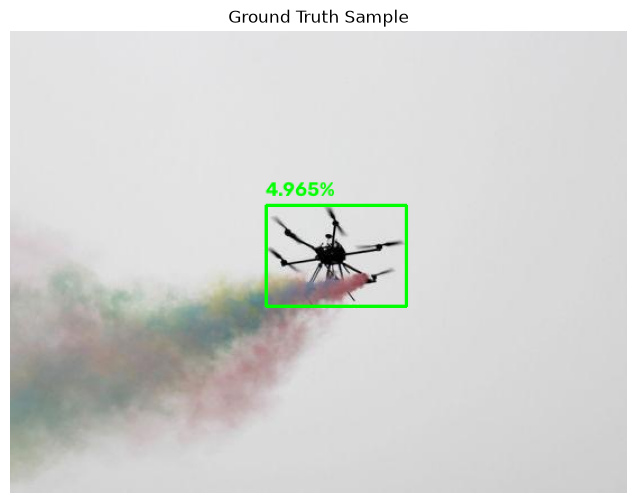

In [38]:
def show_gt(split, image_name, title):
    xml_path = next((DATA_ROOT / split).rglob(f"{image_name}.xml"))
    image_path = next((DATA_ROOT / split).rglob(f"{image_name}.jpg"))
    width, height, boxes = load_xml(xml_path)
    image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)

    for xmin, ymin, xmax, ymax in boxes:
        ratio = (xmax-xmin)*(ymax-ymin)/(width*height)*100
        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
        cv2.putText(image, f"{ratio:.3f}%", (xmin, max(ymin-8, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()


show_gt("train", sample_xml.stem, "Ground Truth Sample")

## 2. 분석용 표 생성

XML을 한 번만 순회하여 이미지 단위 정보와 bbox 단위 정보를 동시에 생성

- 이미지 단위: Split, 이미지명, 크기, 객체 수
- bbox 단위: bbox 너비·높이·면적 비율

In [39]:
image_rows, bbox_rows = [], []

for split in SPLITS:
    for xml_path in sorted((DATA_ROOT / split).rglob("*.xml")):
        width, height, boxes = load_xml(xml_path)
        image_rows.append({"split": split, "image": xml_path.stem, "width": width,
                           "height": height, "object_count": len(boxes)})

        for xmin, ymin, xmax, ymax in boxes:
            bbox_width, bbox_height = xmax-xmin, ymax-ymin
            bbox_rows.append({"split": split, "image": xml_path.stem,
                              "image_width": width, "image_height": height,
                              "bbox_width": bbox_width, "bbox_height": bbox_height,
                              "bbox_area_ratio": bbox_width*bbox_height/(width*height)})

image_df = pd.DataFrame(image_rows)
bbox_df = pd.DataFrame(bbox_rows)
display(image_df.head().rename(columns={"split": "Split", "image": "이미지", "width": "너비",
                                        "height": "높이", "object_count": "객체수"}))
display(bbox_df.head().rename(columns={"split": "Split", "image": "이미지",
                                       "image_width": "이미지너비", "image_height": "이미지높이",
                                       "bbox_width": "bbox너비", "bbox_height": "bbox높이",
                                       "bbox_area_ratio": "bbox면적비율"}))

,Split,이미지,너비,높이,객체수
0,train,00001,550,412,1
1,train,00002,1000,667,1
2,train,00003,511,317,1
3,train,00004,479,261,1
4,train,00005,579,388,1


,Split,이미지,이미지너비,이미지높이,bbox너비,bbox높이,bbox면적비율
0,train,00001,550,412,125,90,0.049647
1,train,00002,1000,667,493,384,0.283826
2,train,00003,511,317,317,204,0.399217
3,train,00004,479,261,276,166,0.366472
4,train,00005,579,388,340,197,0.298150


## 3. bbox 크기와 소형 객체 비율

전체 이미지 대비 bbox 면적 비율을 기준으로 Split별 소형 객체 분포 비교

In [40]:
summary_rows = []
for split in SPLITS:
    data = bbox_df[bbox_df["split"] == split]
    summary_rows.append({
        "Split": split,
        "객체수": len(data),
        "bbox너비_중앙값": data["bbox_width"].median(),
        "bbox높이_중앙값": data["bbox_height"].median(),
        "bbox면적_중앙값(%)": data["bbox_area_ratio"].median()*100,
        "1%미만(%)": data["bbox_area_ratio"].lt(0.01).mean()*100,
        "5%미만(%)": data["bbox_area_ratio"].lt(0.05).mean()*100,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.round(4))

,Split,객체수,bbox너비_중앙값,bbox높이_중앙값,bbox면적_중앙값(%),1%미만(%),5%미만(%)
0,train,5243,43.0,23.0,0.0472,88.3273,94.8312
1,val,2621,42.0,23.0,0.0459,88.5540,94.2388
2,test,2245,55.0,30.0,0.0911,75.8575,92.8285


### 분석 결과

- Train·Validation 객체의 약 88%가 이미지 면적 1% 미만
- Test 객체의 약 76%가 이미지 면적 1% 미만
- Train·Validation bbox 높이 중앙값 23px
- 소형 UAV가 데이터 대부분을 차지하는 고난도 탐지 조건 확인
- Train·Validation의 유사한 크기 분포와 상대적으로 큰 Test 객체 분포 확인

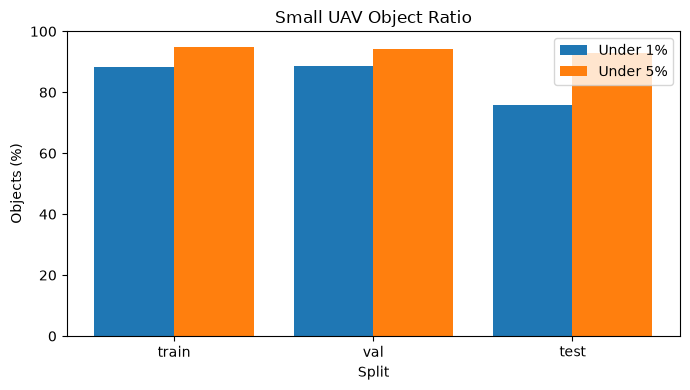

In [52]:
plt.figure(figsize=(7, 4))

x = range(len(summary_df))

plt.bar(
    [i - 0.2 for i in x],
    summary_df['1%미만(%)'],
    width=0.4,
    label='Under 1%'
)

plt.bar(
    [i + 0.2 for i in x],
    summary_df['5%미만(%)'],
    width=0.4,
    label='Under 5%'
)

plt.xticks(x, summary_df['Split'])

plt.title('Small UAV Object Ratio')
plt.xlabel('Split')
plt.ylabel('Objects (%)')
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

### 대표 소형 객체 정성 확인

전체 bbox 면적 비율 중앙값과 가장 가까운 객체를 자동 선택하여 수치와 실제 크기 비교

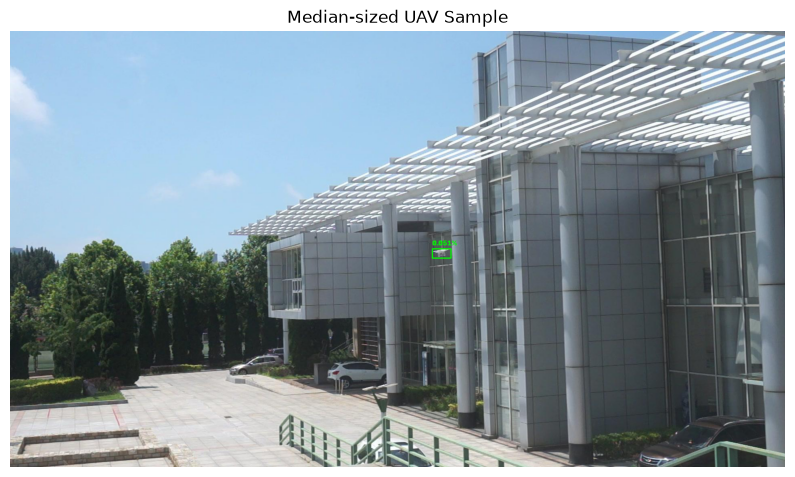

In [42]:
median_ratio = bbox_df["bbox_area_ratio"].median()
sample = bbox_df.loc[(bbox_df["bbox_area_ratio"]-median_ratio).abs().idxmin()]
show_gt(sample["split"], sample["image"], "Median-sized UAV Sample")

### bbox 면적 분포

전체 객체의 bbox 면적 비율 분포와 극단적으로 작은 객체 집중도 확인

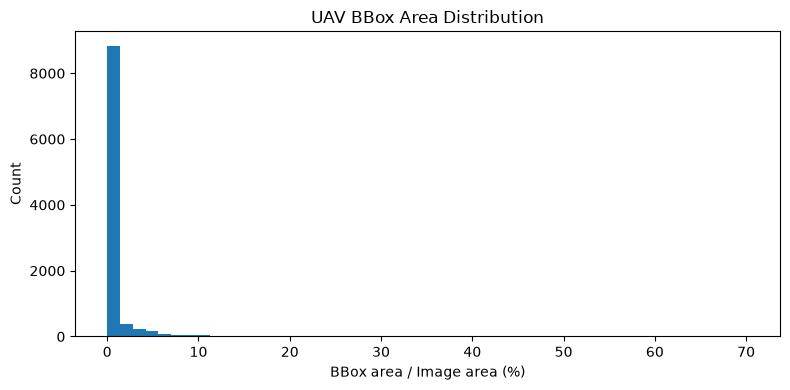

In [43]:
plt.figure(figsize=(8, 4))
plt.hist(bbox_df["bbox_area_ratio"]*100, bins=50)
plt.xlabel("BBox area / Image area (%)")
plt.ylabel("Count")
plt.title("UAV BBox Area Distribution")
plt.tight_layout()
plt.show()

## 4. Input Size 640 기준 예상 bbox 크기

원본 이미지의 긴 변을 640으로 맞추는 비율을 적용한 단순 크기 추정

YOLO letterbox의 padding을 제외한 객체 축소 정도 확인 목적

In [44]:
scale = 640 / bbox_df[["image_width", "image_height"]].max(axis=1)
resized_df = pd.DataFrame({
    "width_640": bbox_df["bbox_width"] * scale,
    "height_640": bbox_df["bbox_height"] * scale,
})
print("640 기준 bbox 너비 중앙값:", round(resized_df["width_640"].median(), 2), "px")
print("640 기준 bbox 높이 중앙값:", round(resized_df["height_640"].median(), 2), "px")
print("한 변이 10px 미만인 객체:", round(resized_df.lt(10).any(axis=1).mean()*100, 2), "%")

640 기준 bbox 너비 중앙값: 15.0 px
640 기준 bbox 높이 중앙값: 8.0 px
한 변이 10px 미만인 객체: 60.95 %


### 분석 결과

- Input Size 640 기준 bbox 너비 중앙값 15px
- Input Size 640 기준 bbox 높이 중앙값 8px
- 한 변이 10px 미만인 객체 60.95%
- 해상도 축소 과정의 특징 및 경계 정보 손실 가능성

## 5. 밝기와 대비

grayscale 평균을 밝기, 표준편차를 대비로 정의하여 Split별 평균 비교

In [45]:
quality_rows = []
for split in SPLITS:
    for image_path in (DATA_ROOT / split).rglob("*.jpg"):
        gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if gray is not None:
            quality_rows.append({"split": split, "brightness": gray.mean(), "contrast": gray.std()})

quality_df = pd.DataFrame(quality_rows)
quality_summary = quality_df.groupby("split")[["brightness", "contrast"]].mean()
display(quality_summary.rename(columns={"brightness": "밝기", "contrast": "대비"}).round(2))

,밝기,대비
split,,
test,122.44,57.16
train,116.06,60.94
val,116.08,60.82


### 분석 결과

- Train과 Validation의 거의 동일한 평균 밝기·대비
- Test의 밝기 약 6 증가와 대비 약 4 감소
- 평균값만으로 개별 저대비 실패를 설명하기 어려운 한계
- 모델 평가 후 실패 이미지 단위의 추가 확인 필요

## 6. 다중 객체와 배경 이미지

빈도가 낮지만 학습과 FP 평가에 중요한 희소 사례 확인

In [46]:
rare_rows = []
for split in SPLITS:
    data = image_df[image_df["split"] == split]
    rare_rows.append({
        "Split": split,
        "이미지수": len(data),
        "배경이미지": data["object_count"].eq(0).sum(),
        "다중객체": data["object_count"].gt(1).sum(),
        "다중객체비율(%)": data["object_count"].gt(1).mean()*100,
        "최대객체수": data["object_count"].max(),
    })

display(pd.DataFrame(rare_rows).round(2))

,Split,이미지수,배경이미지,다중객체,다중객체비율(%),최대객체수
0,train,5200,3,29,0.56,6
1,val,2600,0,13,0.50,6
2,test,2200,0,33,1.50,3


### 희소 사례 정성 확인

배경 이미지 파일명과 객체 수가 가장 많은 이미지를 직접 확인하여 집계 결과 검증

,Split,배경 이미지
578,train,00579
638,train,00639
723,train,00724


최대 객체 수: 6


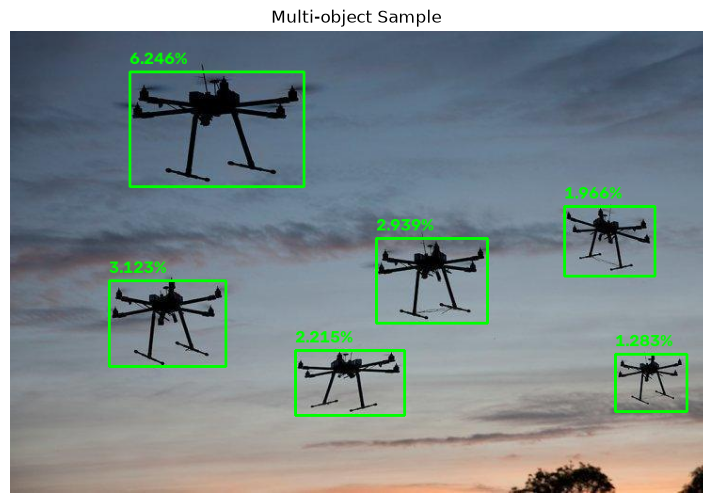

In [47]:
backgrounds = image_df[image_df["object_count"] == 0][["split", "image"]]
display(backgrounds.rename(columns={"split": "Split", "image": "배경 이미지"}))

multi_sample = image_df.loc[image_df["object_count"].idxmax()]
print("최대 객체 수:", multi_sample["object_count"])
show_gt(multi_sample["split"], multi_sample["image"], "Multi-object Sample")

### 분석 결과

| Split | 배경 이미지 | 다중 객체 이미지 | 다중 객체 비율 |
|---|---:|---:|---:|
| Train | 3 | 29 | 0.56% |
| Validation | 0 | 13 | 0.50% |
| Test | 0 | 33 | 1.50% |

- Train에만 존재하는 배경 이미지 3장 확인
- 모든 Split에서 1.5% 이하인 다중 객체 이미지 확인
- 무작위 1/3 추출 시 희소 사례가 대부분 제외될 위험

## 7. Train·Test 유사 이미지 확인

- Train·Test 간 유사 촬영 환경과 유사 프레임 존재 가능성
    - Detection 데이터가 Tracking 영상의 프레임을 그대로 사용한 것은 아니지만, 일부 데이터가 동일하거나 매우 유사한 촬영 환경에서 생성된 것으로 확인됨(https://openaccess.thecvf.com/content/WACV2026W/RWS/papers/Lenhard_Detector-Augmented_SAMURAI_for_Long-Duration_Drone_Tracking_WACVW_2026_paper.pdf?utm_source=chatgpt.com)
- 별도 External Test를 통한 일반화 성능 추가 검증 필요


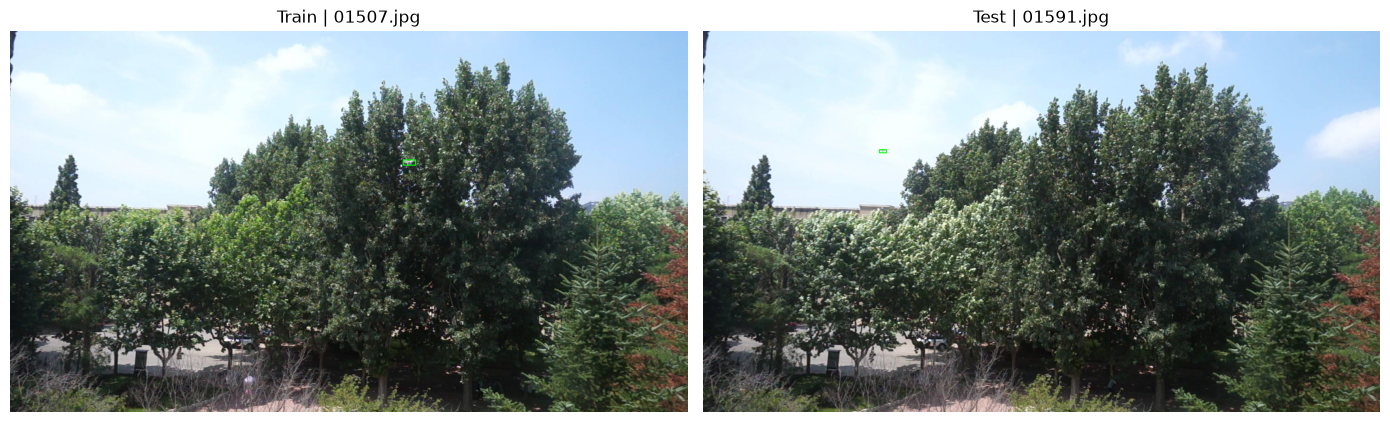

In [48]:
SUBSET_ROOT = PROJECT_ROOT / "data" / "yolo_subset"
TRAIN_IMAGE = "01507.jpg"
TEST_IMAGE = "01591.jpg"


def load_yolo_boxes(label_path):
    boxes = []
    for line in label_path.read_text(encoding="utf-8").splitlines():
        values = line.split()
        if len(values) >= 5:
            _, x, y, w, h = map(float, values[:5])
            boxes.append([x-w/2, y-h/2, x+w/2, y+h/2])
    return boxes


def load_gt_image(split, image_name):
    image_path = SUBSET_ROOT / "images" / split / image_name
    label_path = SUBSET_ROOT / "labels" / split / f"{Path(image_name).stem}.txt"
    image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    height, width = image.shape[:2]

    for x1, y1, x2, y2 in load_yolo_boxes(label_path):
        cv2.rectangle(image, (int(x1*width), int(y1*height)),
                      (int(x2*width), int(y2*height)), (0, 255, 0), 2)
    return image


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, split, image_name in zip(axes, ["train", "test"], [TRAIN_IMAGE, TEST_IMAGE]):
    ax.imshow(load_gt_image(split, image_name))
    ax.set_title(f"{split.title()} | {image_name}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8. 데이터 분석 결론과 서브셋 구성 기준

| 확인 결과 | 서브셋 구성 결정 |
|---|---|
| 이미지 면적 1% 미만 객체가 대부분 | bbox 크기 구간별 균형 추출 |
| Input Size 640에서 한 변 10px 미만 객체 60.95% | 소형 객체 분포 보존 및 후속 크기별 Recall 분석 |
| Train 배경 이미지 3장 | Train 서브셋에 전부 포함 |
| 다중 객체 이미지 비율 0.50~1.50% | Train은 전부 포함, Validation·Test는 원본 비율 유지 |
| Test의 상대적으로 큰 bbox 분포 | 공식 Split 유지 및 Split 간 이동 금지 |
| 유사 연속 프레임 가능성 | 현재 공식 Split 한계로 명시 및 향후 영상 단위 분할 검토 |

임의의 이미지 1쌍만으로 데이터 누수를 단정하지 않고 공식 Split을 유지한 상태에서 한계로 기록

다음 단계에서 원본과 서브셋의 객체 수, 희소 사례와 bbox 분포를 정량 비교하여 대표성 검증